In [1]:
import pandas as pd
import numpy as np

In [4]:
accounts = pd.read_csv("moneycraft_accounts.csv")
closure_reasons = pd.read_csv("moneycraft_closure_reasons.csv")
marketing = pd.read_csv("moneycraft_marketing_spend.csv")

In [6]:
marketing.head()

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0


In [11]:
marketing_analysis = pd.DataFrame()
marketing_analysis['month'] = marketing.groupby('month')['month']
marketing_analysis['spent'] = marketing.groupby('month')['spend_gbp'].sum()
marketing_analysis['branch'] = marketing.groupby('month')['spend_gbp'].sum()
marketing_analysis['broker'] = marketing['channel' = 'Broker/IFA']['spend_gbp']
marketing_analysis['comp'] = marketing.groupby('month')['spend_gbp'].sum()
marketing_analysis['online'] = marketing.groupby('month')['spend_gbp'].sum()
marketing_analysis['out'] = marketing.groupby('month')['spend_gbp'].sum()
marketing_analysis['%_branch'] = marketing.groupby('month')['spend_gbp'].sum()
marketing_analysis['%_broker'] = marketing['channel' = broker['spend_gbp']
marketing_analysis['%_comp'] = marketing.groupby('month')['spend_gbp'].sum()
marketing_analysis['%_online'] = marketing.groupby('month')['spend_gbp'].sum()
marketing_analysis['%_out'] = marketing.groupby('month')['spend_gbp'].sum()

In [14]:
marketing_analysis['broker'] = marketing['channel' == 'Broker/IFA'].sort_values('month')['spend_gbp']

KeyError: False

In [19]:
import pandas as pd

df = pd.read_csv('moneycraft_marketing_spend.csv')

# Total spend per month
total_spend = df.groupby('month')['spend_gbp'].sum().rename('total_spend')

# Spend per month per channel (pivoted into columns)
total_spend_channel = df.pivot_table(index='month', columns='channel', values='spend_gbp', aggfunc='sum')
total_spend_channel.columns = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

# Combine into one dataframe
marketing = total_spend.to_frame().join(total_spend_channel).reset_index()

marketing.head()

,month,total_spend,branch,broker,comp,online,out,refer
0,2022-01,25202.0,7310.0,4014.0,3162.0,3945.0,4899.0,1872.0
1,2022-02,25260.0,7882.0,1989.0,3266.0,4231.0,5548.0,2344.0
2,2022-03,26444.0,6792.0,5159.0,2804.0,5394.0,4134.0,2161.0
3,2022-04,25805.0,9152.0,2358.0,2765.0,5239.0,4415.0,1876.0
4,2022-05,27488.0,7144.0,4637.0,3850.0,5145.0,4894.0,1818.0


KeyError: "None of [Index(['Branch', 'Broker/IFA', 'Comparison Site', 'Online', 'Outbound',\n       'Referral'],\n      dtype='object')] are in the [columns]"

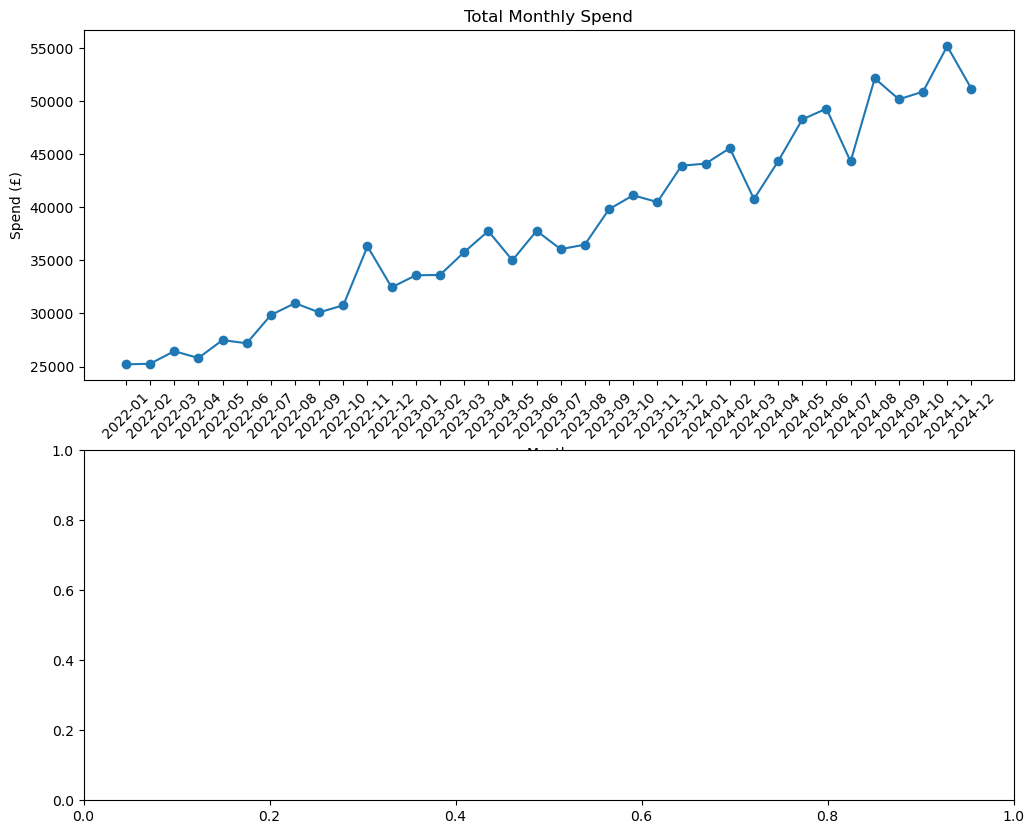

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Plot 1: Total monthly spend ---
axes[0].plot(result['month'], result['total_spend'], marker='o')
axes[0].set_title('Total Monthly Spend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Spend (£)')
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: % spend per channel ---
channels = ['Branch', 'Broker/IFA', 'Comparison Site', 'Online', 'Outbound', 'Referral']

pct_df = result[channels].div(result['total_spend'], axis=0) * 100

for channel in channels:
    axes[1].plot(result['month'], pct_df[channel], marker='o', label=channel)

channel_map = {
    'branch': 'Branch',
    'broker': 'Broker/IFA',
    'online': 'Comparison Site',
    'online': 'Online',
    'out': 'Outbound',
    'refer': 'Referral'
}

for actual_col, display_name in channel_map.items():
    axes[1].plot(result['month'], pct_df[actual_col], marker='o', label=display_name)

axes[1].set_title('Channel Share of Monthly Spend (%)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('% of Total Spend')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('moneycraft_marketing_spend.csv')

# Total spend per month
total_spend = df.groupby('month')['spend_gbp'].sum().rename('total_spend')

# Spend per month per channel
total_spend_channel = df.pivot_table(index='month', columns='channel', values='spend_gbp', aggfunc='sum')
total_spend_channel.columns = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

# Combine into one dataframe
result = total_spend.to_frame().join(total_spend_channel).reset_index()

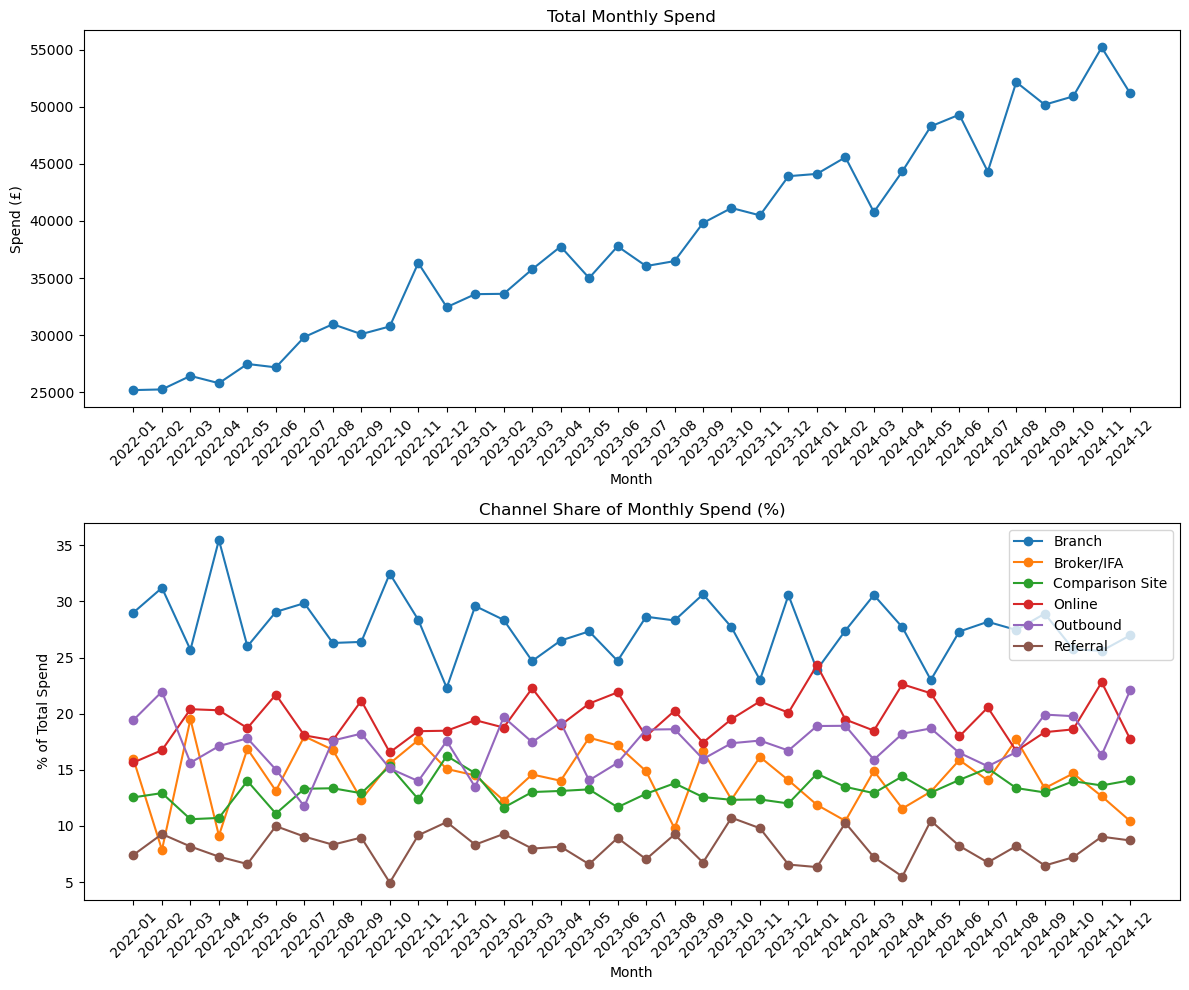

In [24]:
channels = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

channel_map = {
    'branch': 'Branch',
    'broker': 'Broker/IFA',
    'comp': 'Comparison Site',
    'online': 'Online',
    'out': 'Outbound',
    'refer': 'Referral'
}

pct_df = result[channels].div(result['total_spend'], axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Total monthly spend
axes[0].plot(result['month'], result['total_spend'], marker='o')
axes[0].set_title('Total Monthly Spend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Spend (£)')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: % spend per channel
for actual_col, display_name in channel_map.items():
    axes[1].plot(result['month'], pct_df[actual_col], marker='o', label=display_name)

axes[1].set_title('Channel Share of Monthly Spend (%)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('% of Total Spend')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()